# Advanced Temporal Pattern Charts (Solution)

Analyze seasonal/time patterns using calendar heatmap-like and lag plots.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()


## 1) Heatmap year x continent

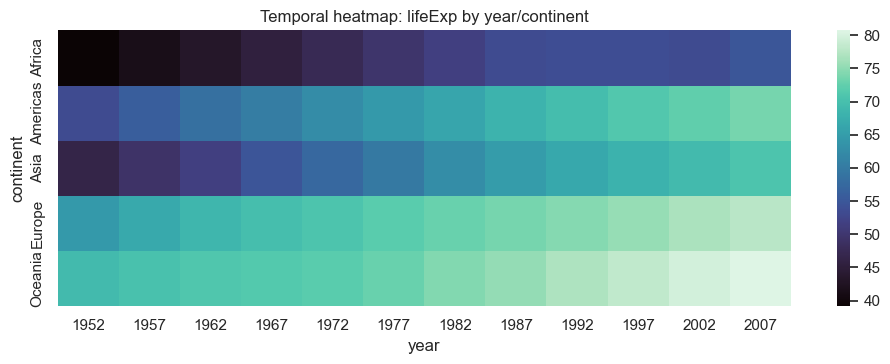

In [2]:
p = df.groupby(['continent','year'],as_index=False)['lifeExp'].mean().pivot(index='continent', columns='year', values='lifeExp')
plt.figure(figsize=(10,3.8))
sns.heatmap(p, cmap='mako')
plt.title('Temporal heatmap: lifeExp by year/continent')
plt.tight_layout(); plt.show()

## 2) Seasonal subseries style (group by decade)

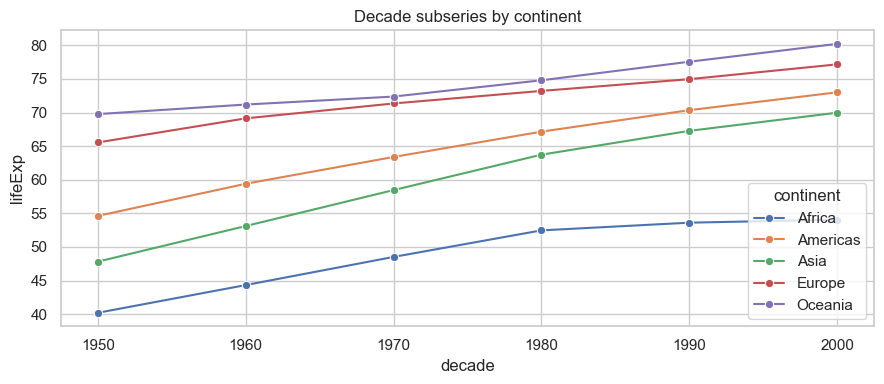

In [3]:
d = df.copy()
d['decade'] = (d['year']//10)*10
s = d.groupby(['decade','continent'],as_index=False)['lifeExp'].mean()
plt.figure(figsize=(9,4))
sns.lineplot(data=s, x='decade', y='lifeExp', hue='continent', marker='o')
plt.title('Decade subseries by continent')
plt.tight_layout(); plt.show()

## 3) Lag plot

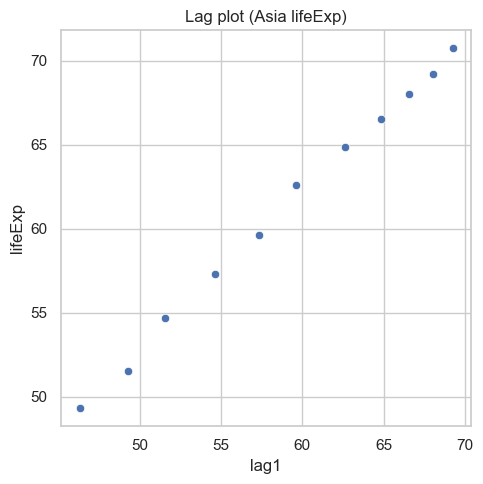

In [4]:
asia = df[df['continent']=='Asia'].groupby('year',as_index=False)['lifeExp'].mean().sort_values('year')
asia['lag1'] = asia['lifeExp'].shift(1)
plt.figure(figsize=(5,5))
sns.scatterplot(data=asia.dropna(), x='lag1', y='lifeExp')
plt.title('Lag plot (Asia lifeExp)')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.